<a href="https://colab.research.google.com/github/nandith2007/2025AIAC/blob/main/B10_2278_ML_ASSIGN_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
d_train = pd.read_csv("/content/train.csv")
d_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
y = d_train['Survived']
X = d_train.drop(['PassengerId', 'Name', 'Ticket', 'Survived', 'Cabin'], axis=1)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (891, 7)
Shape of y: (891,)


In [ ]:
print(f"{y}\n")
print(f"{X}\n")

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

     Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         3    male  22.0      1      0   7.2500        S
1         1  female  38.0      1      0  71.2833        C
2         3  female  26.0      0      0   7.9250        S
3         1  female  35.0      1      0  53.1000        S
4         3    male  35.0      0      0   8.0500        S
..      ...     ...   ...    ...    ...      ...      ...
886       2    male  27.0      0      0  13.0000        S
887       1  female  19.0      0      0  30.0000        S
888       3  female   NaN      1      2  23.4500        S
889       1    male  26.0      0      0  30.0000        C
890       3    male  32.0      0      0   7.7500        Q

[891 rows x 7 columns]



In [ ]:
X["Age"].fillna(X["Age"].median(), inplace=True)
X["Embarked"].fillna(X["Embarked"].mode()[0], inplace=True)
X = pd.get_dummies(X, columns=["Sex", "Embarked"], drop_first=True)

/tmp/ipython-input-816141822.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["Age"].fillna(X["Age"].median(), inplace=True)
/tmp/ipython-input-816141822.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
splits = {
    "70/30": 0.30,
    "80/20": 0.20,
    "90/10": 0.10
}
for split, test_size in splits.items():
    print(f"\n===== Train/Test Split: {split} =====")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


===== Train/Test Split: 70/30 =====
Accuracy: 0.8097014925373134
Confusion Matrix:
 [[136  21]
 [ 30  81]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.84       157
           1       0.79      0.73      0.76       111

    accuracy                           0.81       268
   macro avg       0.81      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268


===== Train/Test Split: 80/20 =====
Accuracy: 0.8100558659217877
Confusion Matrix:
 [[90 15]
 [19 55]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179


===== Train/Test Split: 90/10 =====
Accuracy: 0.8444444444444444
Confusion Matrix:
 [


===== Train/Test Split: 60/40 ====
Accuracy: 0.7564935064935064
ROC-AUC Score: 0.8251951265943271
Confusion Matrix:
 [[168  38]
 [ 37  65]]

===== Train/Test Split: 75/25 ====
Accuracy: 0.7291666666666666
ROC-AUC Score: 0.7942735949098622
Confusion Matrix:
 [[95 28]
 [24 45]]

===== Train/Test Split: 80/20 ====
Accuracy: 0.7532467532467533
ROC-AUC Score: 0.8146923783287419
Confusion Matrix:
 [[79 20]
 [18 37]]


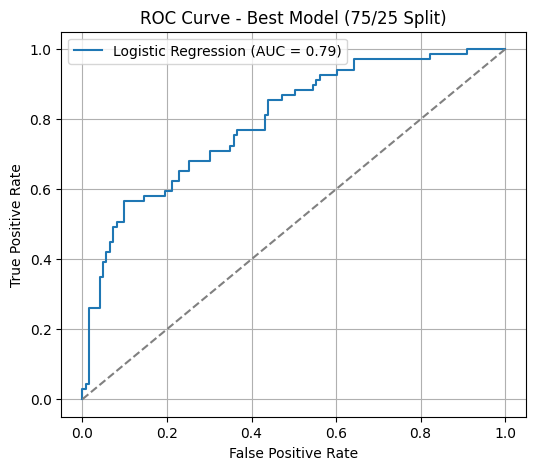

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
# Load dataset
df = pd.read_csv("/content/diabetes (1).csv")
# Separate features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Train/Test split ratios
splits = {
    "60/40": 0.40,
    "75/25": 0.25,
    "80/20": 0.20
}
results = {}
for split, test_size in splits.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42
    )
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    results[split] = {
        "accuracy": acc,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "y_test": y_test,
        "y_prob": y_prob
    }
    print(f"\n===== Train/Test Split: {split} ====")
    print("Accuracy:", acc)
    print("ROC-AUC Score:", roc_auc)
    print("Confusion Matrix:\n", cm)
best = results["75/25"]
fpr, tpr, _ = roc_curve(best["y_test"], best["y_prob"])
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {best['roc_auc']:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Model (75/25 Split)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Load dataset
df = pd.read_csv("/content/heart_disease_uci.csv")
# Separate features and target
X = df.drop("num", axis=1)
y = df["num"]
# Drop the 'dataset' column which is a string and not needed for the model
X = X.drop("dataset", axis=1)
# Handle missing values by imputing with the median (for numerical columns)
for col in X.columns:
    if X[col].dtype in ['int64', 'float64']:
        X[col] = X[col].fillna(X[col].median())
# One-hot encode categorical features
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope",
"ca", "thal"]
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
# Feature scaling
syn_scaler = StandardScaler()
X_scaled = syn_scaler.fit_transform(X)
# Train/Test splits
splits = {
"70/30": 0.30,
"80/20": 0.20,
"85/15": 0.15
}
results = {}
for split, test_size in splits.items():
  X_train, X_test, y_train, y_test = train_test_split(
X_scaled, y, test_size=test_size, random_state=42
)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
results[split] = {
"accuracy": acc,
"precision": report["1"]["precision"],
"recall": report["1"]["recall"],
"f1": report["1"]["f1-score"],
"confusion_matrix": cm
}
print(f"\n===== Train/Test Split: {split} ====")
print("Accuracy:", acc)
print("Precision:", report["1"]["precision"])
print("Recall:", report["1"]["recall"])
print("F1-score:", report["1"]["f1-score"])


===== Train/Test Split: 85/15 ====
Accuracy: 0.5652173913043478
Precision: 0.46511627906976744
Recall: 0.5
F1-score: 0.4819277108433735


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


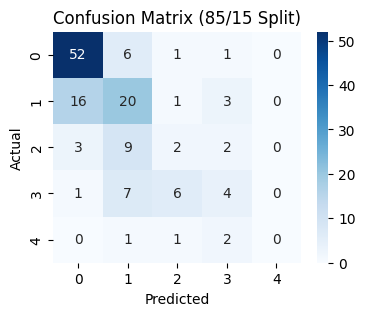

In [ ]:
for split in results:
    plt.figure(figsize=(4, 3))
    sns.heatmap(results[split]["confusion_matrix"],annot=True,fmt="d",cmap="Blues")
    plt.title(f"Confusion Matrix ({split} Split)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score
)

# Load dataset (Titanic train.csv)
df = pd.read_csv("/content/train.csv")

# Separate features and target
y = df['Survived']
X = df.drop(['PassengerId', 'Name', 'Ticket', 'Survived', 'Cabin'], axis=1)

# Handle missing values and encode categorical features
X["Age"].fillna(X["Age"].median(), inplace=True)
X["Embarked"].fillna(X["Embarked"].mode()[0], inplace=True)
X = pd.get_dummies(X, columns=["Sex", "Embarked"], drop_first=True)

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test splits
splits = {
    "50/50": 0.50,
    "70/30": 0.30,
    "80/20": 0.20
}

for split, test_size in splits.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42
    )
    model = LogisticRegression(max_iter=5000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n===== Train/Test Split: {split} ====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


===== Train/Test Split: 50/50 ====
Accuracy: 0.8071748878923767
ROC-AUC: 0.8554809281693971
Confusion Matrix:
 [[233  34]
 [ 52 127]]

===== Train/Test Split: 70/30 ====
Accuracy: 0.8097014925373134
ROC-AUC: 0.8797268606185804
Confusion Matrix:
 [[136  21]
 [ 30  81]]

===== Train/Test Split: 80/20 ====
Accuracy: 0.8100558659217877
ROC-AUC: 0.881981981981982
Confusion Matrix:
 [[90 15]
 [19 55]]


/tmp/ipython-input-1106516783.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["Age"].fillna(X["Age"].median(), inplace=True)
/tmp/ipython-input-1106516783.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)
# Load dataset
df = pd.read_csv("/content/Social_Network_Ads.csv")
# Select features and target
X = df[["Age", "EstimatedSalary"]]
y = df["Purchased"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
splits = {
    "65/35": 0.35,
    "75/25": 0.25,
    "80/20": 0.20
}
results = {}
for split, test_size in splits.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42
    )
    model = LogisticRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    results[split] = {
        "model": model,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "accuracy": acc
    }
    print(f"\n===== Train/Test Split: {split} ====")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", report)


===== Train/Test Split: 65/35 ====
Accuracy: 0.8357142857142857
Confusion Matrix:
 [[82  2]
 [21 35]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.98      0.88        84
           1       0.95      0.62      0.75        56

    accuracy                           0.84       140
   macro avg       0.87      0.80      0.81       140
weighted avg       0.86      0.84      0.83       140


===== Train/Test Split: 75/25 ====
Accuracy: 0.86
Confusion Matrix:
 [[61  2]
 [12 25]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.97      0.90        63
           1       0.93      0.68      0.78        37

    accuracy                           0.86       100
   macro avg       0.88      0.82      0.84       100
weighted avg       0.87      0.86      0.85       100


===== Train/Test Split: 80/20 ====
Accuracy: 0.8625
Confusion Matrix:
 [[50  2]
 [ 9 19]]
Classification 

<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

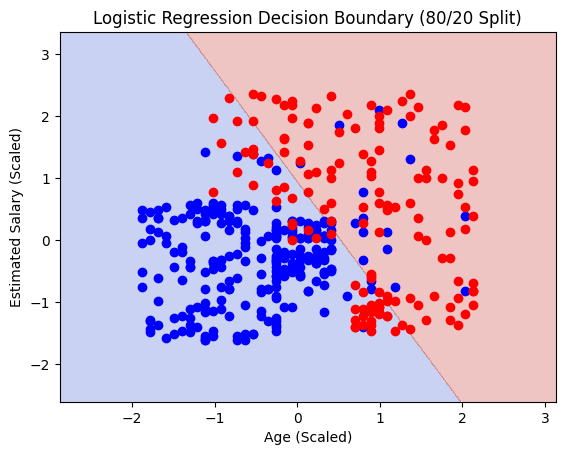

In [ ]:
# Retrieve best model
best = results["80/20"]
model = best["model"]
X_set, y_set = best["X_train"], best["y_train"]
# Create grid
X1, X2 = np.meshgrid(
np.arange(X_scaled[:, 0].min()-1, X_scaled[:, 0].max()+1, 0.01),
np.arange(X_scaled[:, 1].min()-1, X_scaled[:, 1].max()+1, 0.01)
)
plt.contourf(
X1, X2,
model.predict(np.array([X1.ravel(),
X2.ravel()]).T).reshape(X1.shape),
alpha=0.3,
cmap="coolwarm"
)
# Plot points
plt.scatter(X_scaled[y == 0, 0], X_scaled[y == 0, 1], color="blue",
label="Not Purchased")
plt.scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1], color="red",
label="Purchased")
plt.xlabel("Age (Scaled)")
plt.ylabel("Estimated Salary (Scaled)")
plt.title("Logistic Regression Decision Boundary (80/20 Split)")
plt.legend